In [30]:
%pip install matplotlib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns  # for the heatmap

Note: you may need to restart the kernel to use updated packages.


In [2]:
#fetching stock data
df =yf.download("TCS.NS", period = "2y")

[*********************100%***********************]  1 of 1 completed


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 494 entries, 2024-04-15 to 2026-04-13
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   494 non-null    float64
 1   (High, TCS.NS)    494 non-null    float64
 2   (Low, TCS.NS)     494 non-null    float64
 3   (Open, TCS.NS)    494 non-null    float64
 4   (Volume, TCS.NS)  494 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.2 KB


In [4]:
df

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2024-04-15,3696.099854,3811.450581,3675.327436,3752.556017,4200329
2024-04-16,3631.953613,3684.377144,3622.622442,3659.337642,3051420
2024-04-18,3621.824707,3691.222695,3610.570979,3635.704350,3476284
2024-04-19,3588.251465,3612.962870,3564.524807,3599.317678,2957749
2024-04-22,3624.263428,3636.830000,3574.934492,3598.379760,1728883
...,...,...,...,...,...
2026-04-07,2539.800049,2543.899902,2448.000000,2461.000000,4516550
2026-04-08,2559.199951,2580.300049,2540.100098,2572.000000,4769337


In [5]:
df.isnull().sum() #checking null values 

Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64

In [6]:
df.dropna(inplace = True)

In [7]:
df.reset_index(inplace = True) #resetting the index to normal from date 

In [8]:
df.drop_duplicates(inplace = True) #removing the duplicate rows 

In [9]:
# Flatten columns
df.columns = [col[0] for col in df.columns]
#renaming column names
df.columns = ['Date','Close','High','Low','Open','Volume']

In [10]:
#daily change 
df['Daily_Return'] = df['Close'].pct_change()

In [11]:
#m50 and m200
df['M50'] = df['Close'].rolling(window = 50).mean()
df['M200'] = df['Close'].rolling(window = 200).mean()

In [12]:
#Price Change
df['Price_Change'] = df['Close'] - df['Open']

In [13]:
#average daily return 
average_return = df['Daily_Return'].mean()
print("Average Daily Return is - ", average_return)

Average Daily Return is -  -0.000723733568487231


In [14]:
#volatility
volatility = df['Daily_Return'].std() * np.sqrt(252)
print("Volatility is - ", volatility)

Volatility is -  0.214749598106498


In [15]:
#cumulative return 
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()

In [16]:
#max drawdown
cum = df['Cumulative_Return']
peak = cum.cummax()
drawdown = (cum - peak) / peak
max_drawdown = drawdown.mean()
print("Max Draw Down is - ", max_drawdown)

Max Draw Down is -  -0.18231250038943456


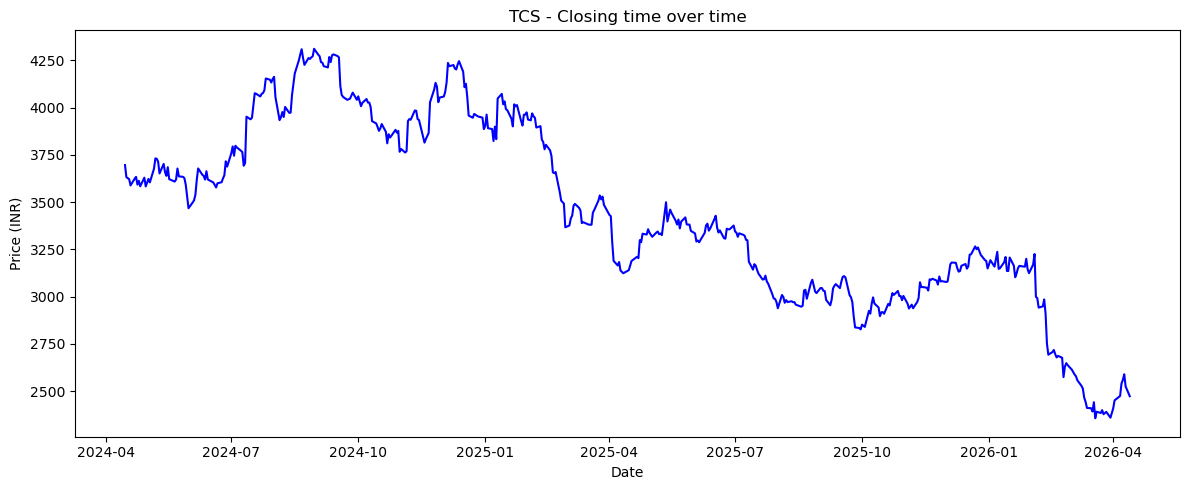

In [17]:
# PLOT 1: Closing Price Over Time
# Shows the raw price history of the stock
plt.figure(figsize = (12,5))
plt.plot(df['Date'], df['Close'], color = 'blue', linewidth = 1.5) 
plt.title("TCS - Closing time over time")
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

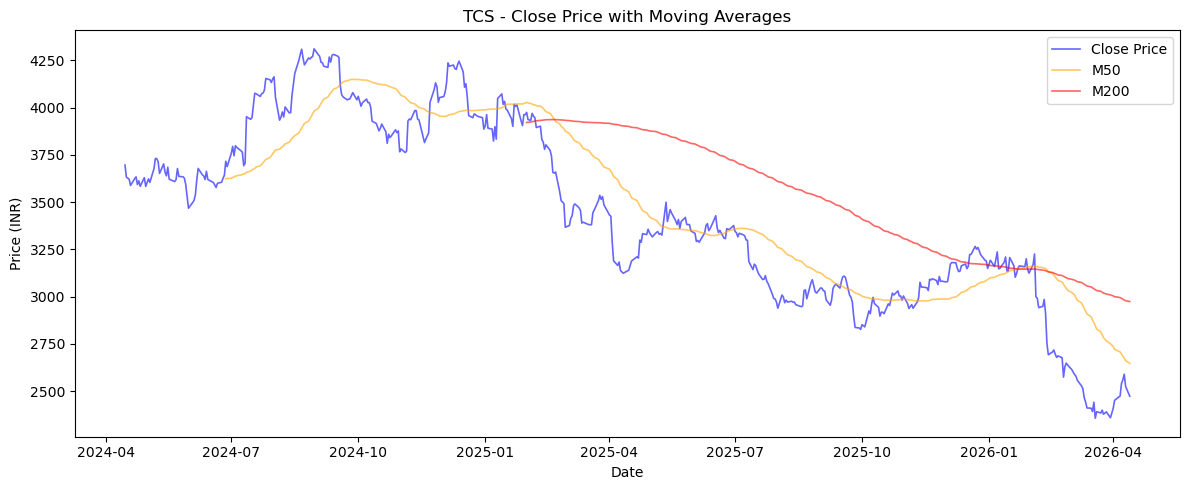

In [18]:
#Plot 2 close m50 and m200
plt.figure(figsize = (12,5)) 
plt.plot(df['Date'], df['Close'], label = 'Close Price', color = 'Blue', linewidth = 1.2, alpha = 0.6)
plt.plot(df['Date'], df['M50'], label = 'M50', color ='Orange', linewidth = 1.2, alpha = 0.6)
plt.plot(df['Date'], df['M200'], label = 'M200', color ='Red', linewidth = 1.2, alpha = 0.6)
plt.title('TCS - Close Price with Moving Averages') 
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

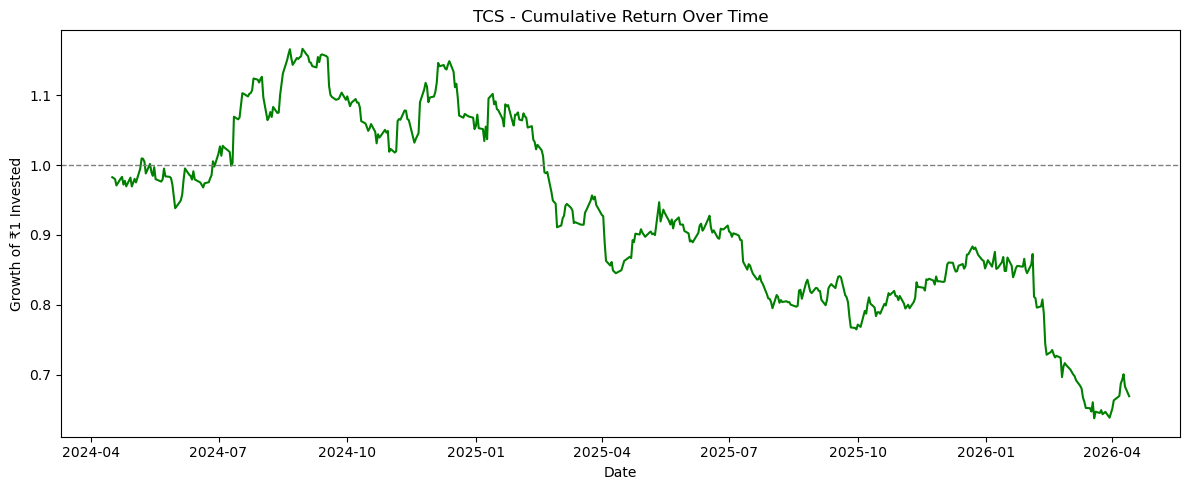

In [19]:
# ──────────────────────────────────────────────
# PLOT 3: Cumulative Return Over Time
# Shows how ₹1 invested at the start would grow
# A rising line = stock is gaining overall
# ──────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Cumulative_Return'], color='green', linewidth=1.5)
plt.title('TCS - Cumulative Return Over Time')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 Invested')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)  # baseline: break-even
plt.tight_layout()
plt.show()


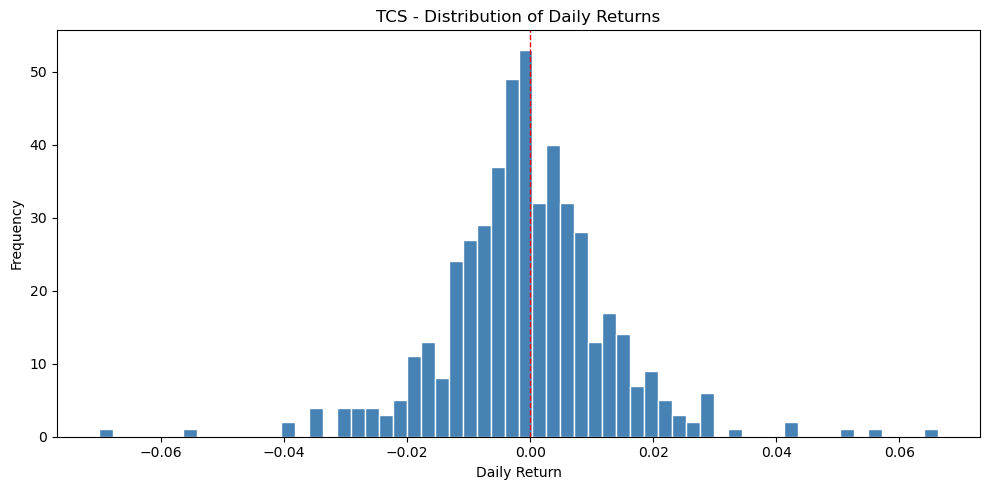

In [20]:
# ──────────────────────────────────────────────
# PLOT 4: Distribution of Daily Returns (Histogram)
# Shows how often the stock gains or loses each day
# Narrow + centered near 0 → stable, low volatility
# Wide spread → high volatility, more risk/reward
# ──────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.hist(df['Daily_Return'].dropna(), bins=60, color='steelblue', edgecolor='white')
plt.title('TCS - Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)  # marks zero return
plt.tight_layout()
plt.show()

In [22]:
# Moving Average Crossover Strategy
df['Signal'] = np.where(
    df['M50']>df['M200'],
    1,
    np.where(df['M200']>df['M50'],
             -1,
             0)
)
df['Signal'].value_counts()

Signal
-1    262
 0    199
 1     33
Name: count, dtype: int64

In [24]:
df[['Date', 'Close', 'M50', 'M200', 'Signal']].dropna().tail(10)

,Date,Close,M50,M200,Signal
484,2026-03-27,2389.800049,2765.980005,3013.821731,-1
485,2026-03-30,2358.899902,2750.448003,3008.731361,-1
486,2026-04-01,2408.199951,2735.902002,3003.843607,-1
487,2026-04-02,2450.699951,2720.782002,2999.352177,-1
488,2026-04-06,2473.899902,2706.987998,2994.920673,-1
489,2026-04-07,2539.800049,2695.737998,2990.571946,-1
490,2026-04-08,2559.199951,2684.469995,2986.227577,-1
491,2026-04-09,2589.000000,2673.241997,2982.343781,-1
492,2026-04-10,2524.300049,2660.477998,2978.270085,-1
493,2026-04-13,2472.600098,2646.770000,2973.880841,-1


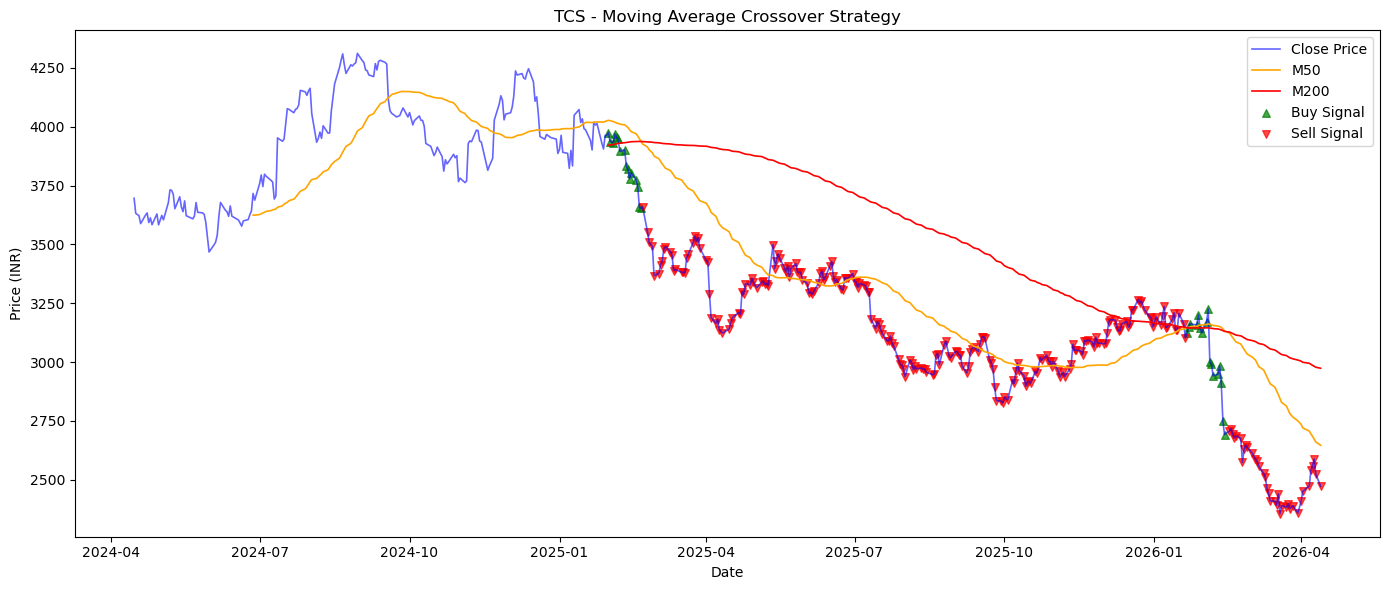

In [25]:
# ──────────────────────────────────────────────
# Optional: Visualize the signals on the price chart
# Green triangle (^) = Buy, Red triangle (v) = Sell
# ──────────────────────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='blue', linewidth=1.2, alpha=0.6, label='Close Price')
plt.plot(df['Date'], df['M50'],  color='orange', linewidth=1.2, label='M50')
plt.plot(df['Date'], df['M200'], color='red',    linewidth=1.2, label='M200')
# Plot Buy signals as green upward triangles
buy_signals = df[df['Signal'] == 1]
plt.scatter(buy_signals['Date'], buy_signals['Close'],
            marker='^', color='green', s=30, label='Buy Signal', alpha=0.7)
# Plot Sell signals as red downward triangles
sell_signals = df[df['Signal'] == -1]
plt.scatter(sell_signals['Date'], sell_signals['Close'],
            marker='v', color='red', s=30, label='Sell Signal', alpha=0.7)
plt.title('TCS - Moving Average Crossover Strategy')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

Market Final Return:   0.67x  (-33.10%)
Strategy Final Return: 0.98x  (-1.82%)
Result: Strategy BEAT the market


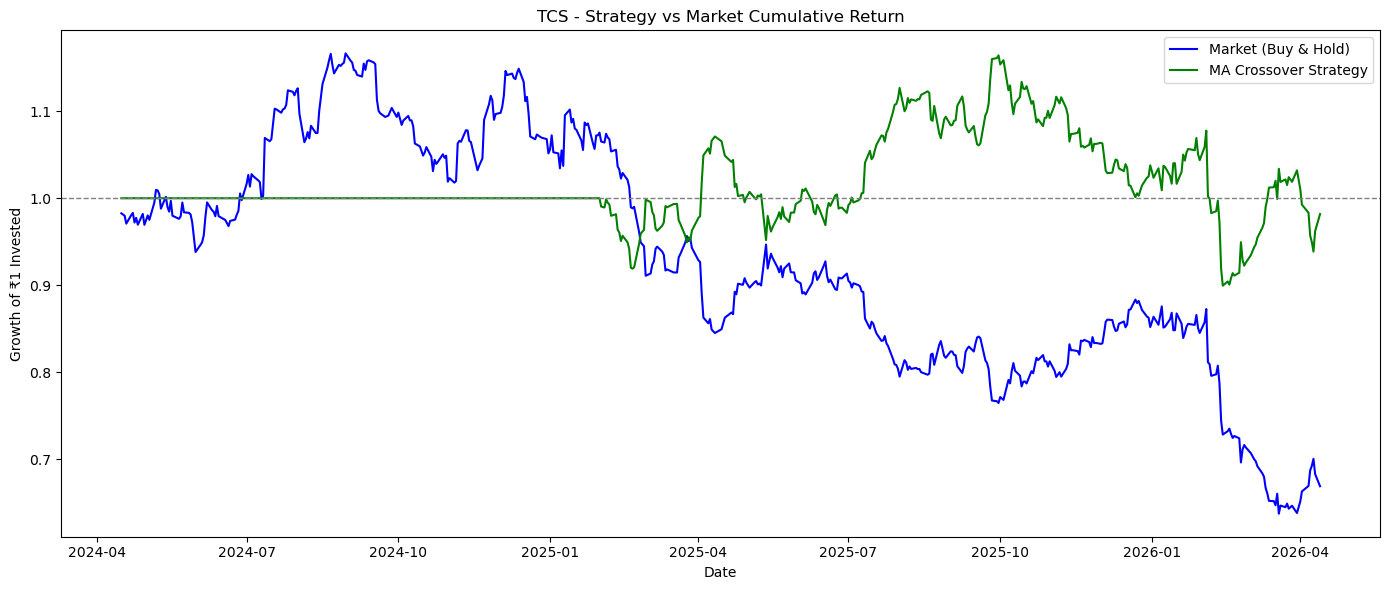

In [27]:
# ──────────────────────────────────────────────
# PHASE 7: STRATEGY EVALUATION
# Compare Strategy Returns vs Market Returns
# ──────────────────────────────────────────────

# Step 1: Calculate Strategy Daily Return
# Shift signal by 1 day — today's signal acts on tomorrow's return
# This avoids "look-ahead bias" (using future info to make past decisions)
df['Strategy_Return'] = df['Daily_Return'] * df['Signal'].shift(1)

# Step 2: Calculate Cumulative Returns for both
# Market: what you get by just holding the stock
# Strategy: what you get by following the Buy/Sell signals
df['Market_Cumulative']   = (1 + df['Daily_Return']).cumprod()
df['Strategy_Cumulative'] = (1 + df['Strategy_Return']).cumprod()

# ──────────────────────────────────────────────
# Step 3: Print final performance numbers
# ──────────────────────────────────────────────
market_final   = df['Market_Cumulative'].iloc[-1]
strategy_final = df['Strategy_Cumulative'].iloc[-1]

print(f"Market Final Return:   {market_final:.2f}x  ({(market_final - 1) * 100:.2f}%)")
print(f"Strategy Final Return: {strategy_final:.2f}x  ({(strategy_final - 1) * 100:.2f}%)")

if strategy_final > market_final:
    print("Result: Strategy BEAT the market")
else:
    print("Result: Strategy UNDERPERFORMED the market")

# ──────────────────────────────────────────────
# Step 4: Plot both cumulative returns on one chart
# ──────────────────────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Market_Cumulative'],   color='blue',  linewidth=1.5, label='Market (Buy & Hold)')
plt.plot(df['Date'], df['Strategy_Cumulative'], color='green', linewidth=1.5, label='MA Crossover Strategy')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)  # break-even line
plt.title('TCS - Strategy vs Market Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 Invested')
plt.legend()
plt.tight_layout()
plt.show()

[*********************100%***********************]  4 of 4 completed


Close Prices Shape: (1481, 4)
                   TCS     Reliance      Infosys         HDFC
Date                                                         
2023-12-22  813.178833  1471.446777  1273.102295  3561.376953
2023-12-26  818.824463  1453.605591  1279.554443  3534.881104
2023-12-27  828.971863  1475.401001  1283.922241  3549.456299
2023-12-28  829.920837  1471.211304  1293.203491  3538.932129
2023-12-29  831.867615  1452.617065  1282.979004  3532.878662

Stock Summary:
          Avg Daily Return  Volatility (Annual)  Total Cumulative Return
TCS                 0.0006               0.2545                   0.9226
Reliance            0.0010               0.2803                   2.4982
Infosys             0.0010               0.2981                   2.1926
HDFC                0.0009               0.2495                   2.2598


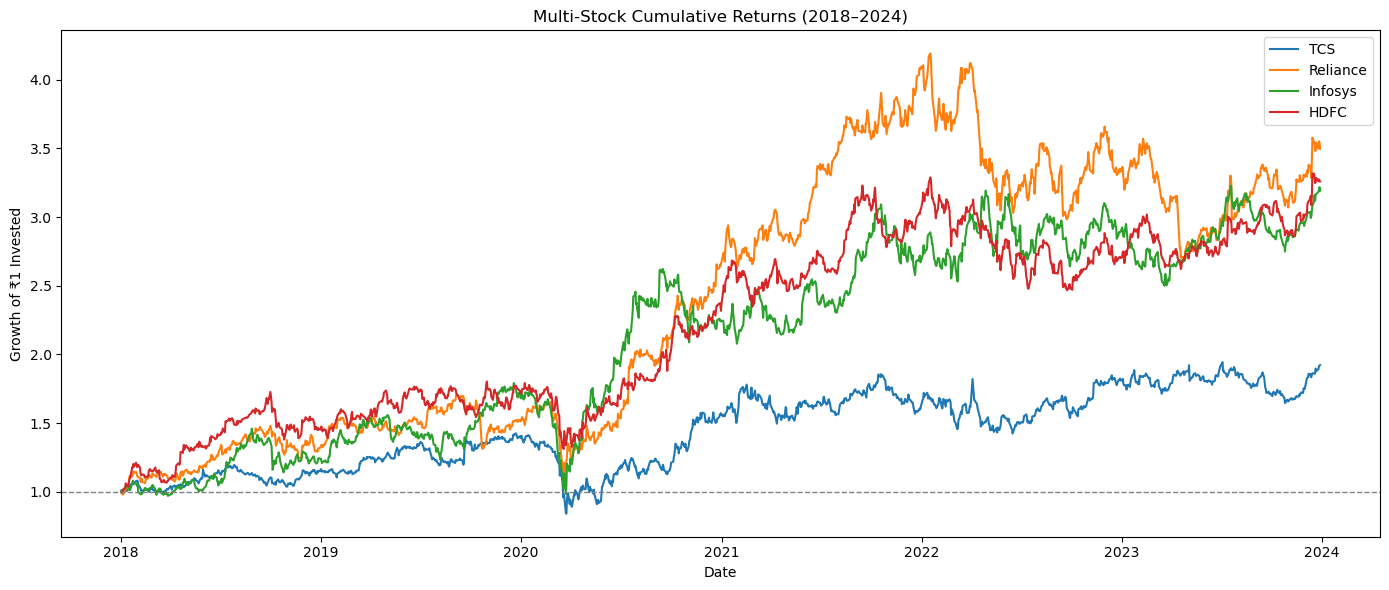

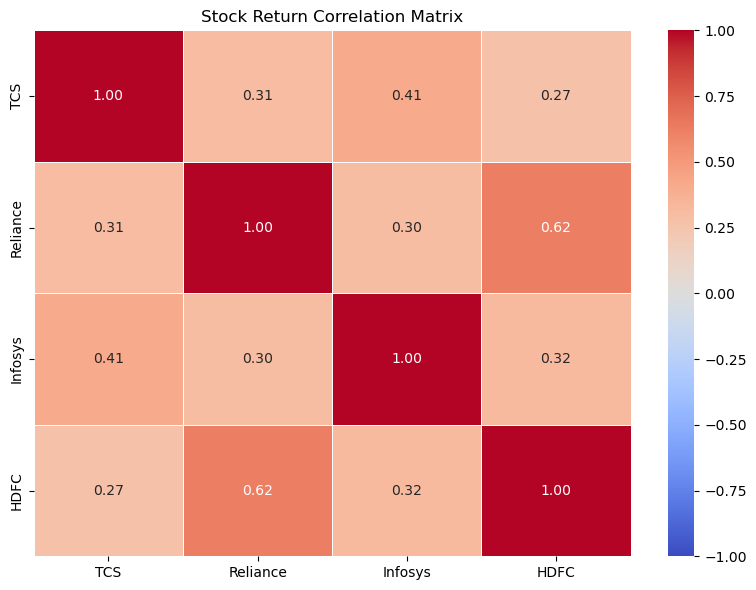

In [31]:
# ──────────────────────────────────────────────
# PHASE 8: MULTI-STOCK ANALYSIS
# ──────────────────────────────────────────────

# Step 1: Define the stocks and download data
tickers = ['TCS.NS', 'RELIANCE.NS', 'INFY.NS', 'HDFCBANK.NS']

raw = yf.download(tickers, start='2018-01-01', end='2024-01-01')

# Step 2: Extract only the Close prices for all stocks
# This gives a dataframe where each column = one stock's close price
close_prices = raw['Close']
close_prices.columns = ['TCS', 'Reliance', 'Infosys', 'HDFC']  # rename for clarity

print("Close Prices Shape:", close_prices.shape)
print(close_prices.tail(5))

# ──────────────────────────────────────────────
# Step 3: Calculate Daily Returns for all stocks at once
# pct_change() works on the entire dataframe in one go
# ──────────────────────────────────────────────
daily_returns = close_prices.pct_change()

# ──────────────────────────────────────────────
# Step 4: Build a Summary Table
# Average return and volatility for each stock
# ──────────────────────────────────────────────
summary = pd.DataFrame({
    'Avg Daily Return': daily_returns.mean(),
    'Volatility (Annual)': daily_returns.std() * np.sqrt(252),
    'Total Cumulative Return': (1 + daily_returns).cumprod().iloc[-1] - 1
})

print("\nStock Summary:")
print(summary.round(4))

# ──────────────────────────────────────────────
# Step 5: Plot Cumulative Returns — all stocks together
# ──────────────────────────────────────────────
cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(14, 6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col, linewidth=1.5)

plt.title('Multi-Stock Cumulative Returns (2018–2024)')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 Invested')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Step 6: Correlation Heatmap
# Shows how closely each pair of stocks moves together
# ──────────────────────────────────────────────
correlation = daily_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,        # show the numbers inside each cell
    fmt='.2f',         # round to 2 decimal places
    cmap='coolwarm',   # red = high correlation, blue = low
    vmin=-1, vmax=1,   # fix the color scale from -1 to 1
    linewidths=0.5
)
plt.title('Stock Return Correlation Matrix')
plt.tight_layout()
plt.show()

In [32]:
# ──────────────────────────────────────────────
# PHASE 9: INSIGHTS & EXPLANATION
# Print a full summary of everything computed
# ──────────────────────────────────────────────

print("=" * 55)
print("       STOCK ANALYSIS REPORT — TCS.NS")
print("=" * 55)

# ── Section 1: Basic Info ──────────────────────
print("\n[ 1 ] DATA OVERVIEW")
print(f"  Total trading days : {len(df)}")
print(f"  Start date         : {df['Date'].iloc[0].date()}")
print(f"  End date           : {df['Date'].iloc[-1].date()}")
print(f"  Starting price     : ₹{df['Close'].iloc[0]:.2f}")
print(f"  Ending price       : ₹{df['Close'].iloc[-1]:.2f}")

# ── Section 2: Feature Check ───────────────────
print("\n[ 2 ] FEATURE ENGINEERING CHECK")
print(f"  M50  — NaN rows    : {df['M50'].isna().sum()}")
print(f"  M200 — NaN rows    : {df['M200'].isna().sum()}")
print(f"  Daily_Return NaNs  : {df['Daily_Return'].isna().sum()}")

# ── Section 3: Risk & Performance ─────────────
avg_return   = df['Daily_Return'].mean()
volatility   = df['Daily_Return'].std() * (252 ** 0.5)
cum_return   = (1 + df['Daily_Return']).cumprod().iloc[-1]

rolling_max  = df['Close'].cummax()
drawdown     = (df['Close'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print("\n[ 3 ] RISK & PERFORMANCE METRICS")
print(f"  Avg Daily Return   : {avg_return * 100:.4f}%")
print(f"  Annual Volatility  : {volatility * 100:.2f}%")
print(f"  Cumulative Return  : {cum_return:.2f}x  ({(cum_return - 1) * 100:.2f}%)")
print(f"  Max Drawdown       : {max_drawdown * 100:.2f}%")

# ── Section 4: Signal Distribution ────────────
buy_days  = (df['Signal'] == 1).sum()
sell_days = (df['Signal'] == -1).sum()
hold_days = (df['Signal'] == 0).sum()

print("\n[ 4 ] STRATEGY SIGNALS (M50 vs M200)")
print(f"  Buy  days (M50 > M200) : {buy_days}")
print(f"  Sell days (M50 < M200) : {sell_days}")
print(f"  Hold days              : {hold_days}")

# ── Section 5: Strategy vs Market ─────────────
market_final   = df['Market_Cumulative'].iloc[-1]
strategy_final = df['Strategy_Cumulative'].iloc[-1]

print("\n[ 5 ] STRATEGY EVALUATION")
print(f"  Market Return   : {market_final:.2f}x  ({(market_final - 1) * 100:.2f}%)")
print(f"  Strategy Return : {strategy_final:.2f}x  ({(strategy_final - 1) * 100:.2f}%)")

if strategy_final > market_final:
    diff = (strategy_final - market_final) * 100
    print(f"  Result: Strategy BEAT the market by {diff:.2f}%")
else:
    diff = (market_final - strategy_final) * 100
    print(f"  Result: Strategy UNDERPERFORMED by {diff:.2f}%")

print("\n[ 6 ] INTERPRETATION")
print("  - M50 crossing above M200 signals a bullish trend (Golden Cross)")
print("  - M50 crossing below M200 signals a bearish trend (Death Cross)")
print("  - Moving averages are lagging — they react after the move happens")
print("  - Strategy works best in steady trending markets, not volatile ones")

print("\n" + "=" * 55)
print("               END OF REPORT")
print("=" * 55)

       STOCK ANALYSIS REPORT — TCS.NS

[ 1 ] DATA OVERVIEW
  Total trading days : 494
  Start date         : 2024-04-15
  End date           : 2026-04-13
  Starting price     : ₹3696.10
  Ending price       : ₹2472.60

[ 2 ] FEATURE ENGINEERING CHECK
  M50  — NaN rows    : 49
  M200 — NaN rows    : 199
  Daily_Return NaNs  : 1

[ 3 ] RISK & PERFORMANCE METRICS
  Avg Daily Return   : -0.0724%
  Annual Volatility  : 21.47%
  Cumulative Return  : 0.67x  (-33.10%)
  Max Drawdown       : -45.36%

[ 4 ] STRATEGY SIGNALS (M50 vs M200)
  Buy  days (M50 > M200) : 33
  Sell days (M50 < M200) : 262
  Hold days              : 199

[ 5 ] STRATEGY EVALUATION
  Market Return   : 0.67x  (-33.10%)
  Strategy Return : 0.98x  (-1.82%)
  Result: Strategy BEAT the market by 31.29%

[ 6 ] INTERPRETATION
  - M50 crossing above M200 signals a bullish trend (Golden Cross)
  - M50 crossing below M200 signals a bearish trend (Death Cross)
  - Moving averages are lagging — they react after the move happens
  - St

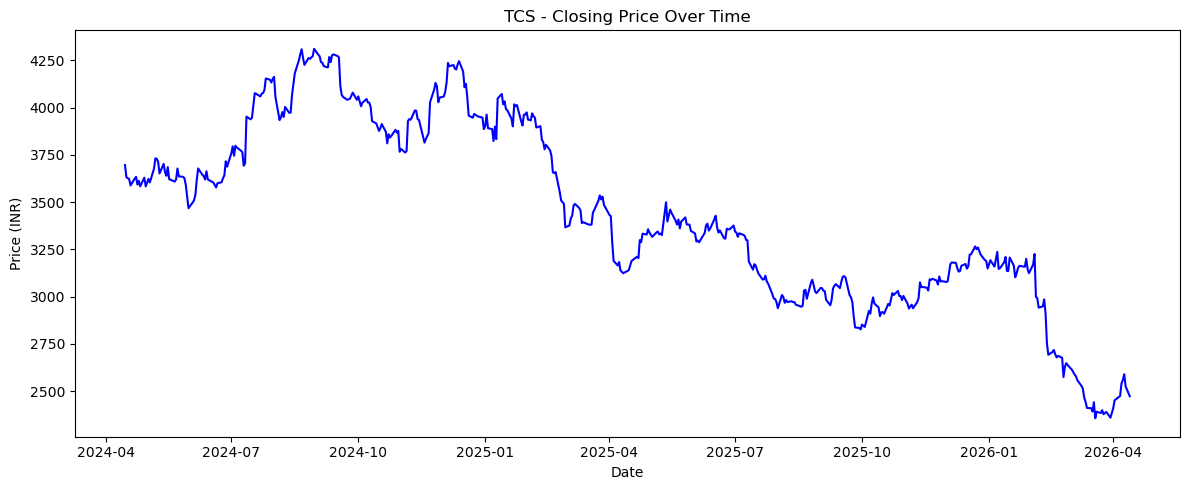

Saved: 01_closing_price.png


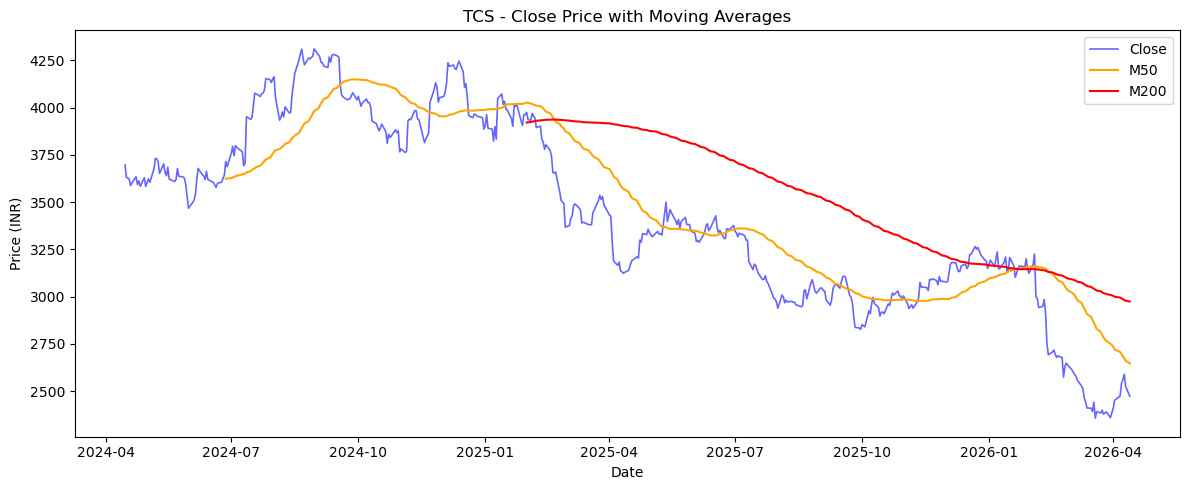

Saved: 02_moving_averages.png


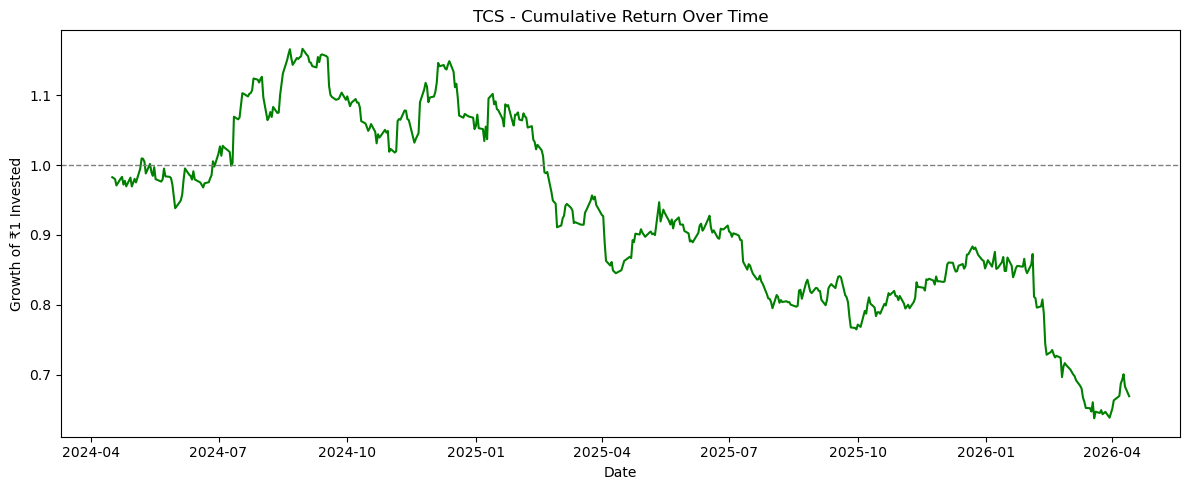

Saved: 03_cumulative_return.png


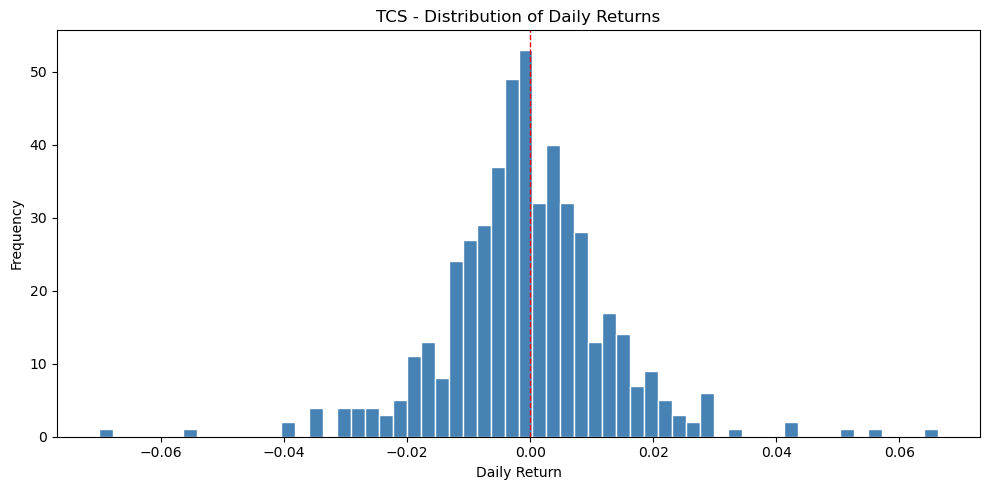

Saved: 04_daily_return_dist.png


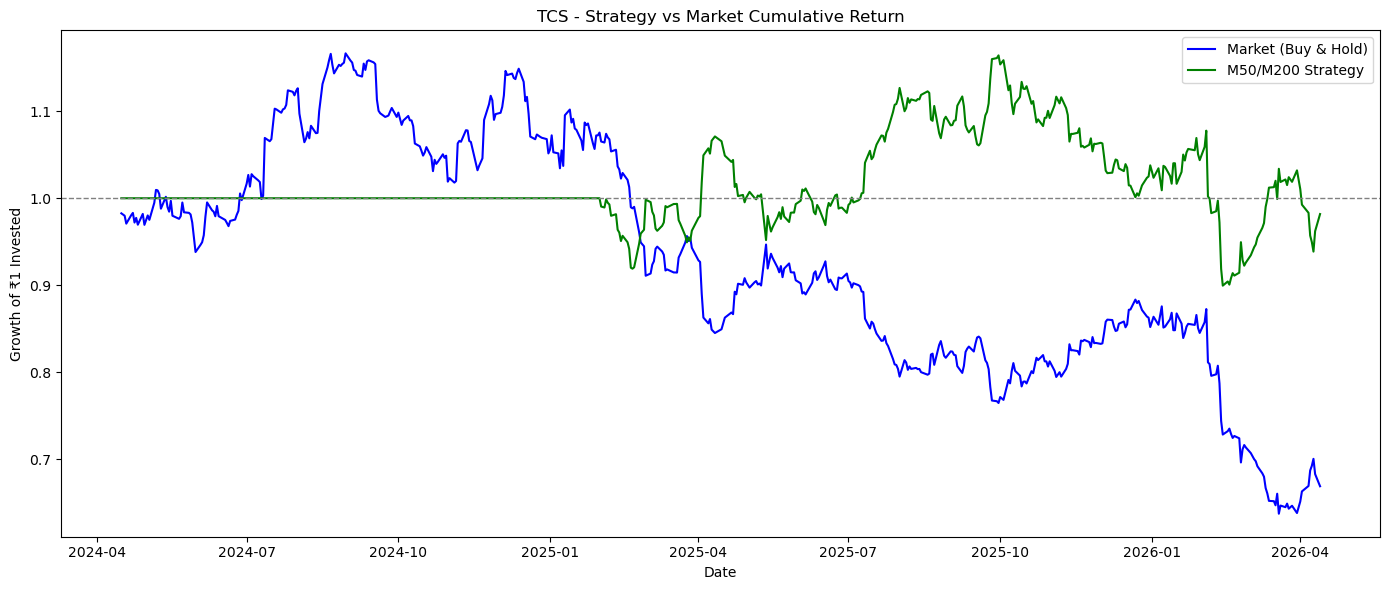

Saved: 05_strategy_vs_market.png
Saved: tcs_analysis_final.csv
Saved: summary_metrics.csv

 All outputs saved to the 'outputs/' folder:
   - 01_closing_price.png
   - 02_moving_averages.png
   - 03_cumulative_return.png
   - 04_daily_return_dist.png
   - 05_strategy_vs_market.png
   - summary_metrics.csv
   - tcs_analysis_final.csv


In [34]:
import os

# ──────────────────────────────────────────────
# PHASE 10: FINAL POLISHING
# Save charts, export results, clean up output
# ──────────────────────────────────────────────

# Step 1: Create a folder to save all outputs
os.makedirs('outputs', exist_ok=True)

# ── Save Chart 1: Closing Price ────────────────
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='blue', linewidth=1.5)
plt.title('TCS - Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.savefig('outputs/01_closing_price.png', dpi=150)
plt.show()
print("Saved: 01_closing_price.png")

# ── Save Chart 2: Close + M50 + M200 ──────────
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close', color='blue', linewidth=1.2, alpha=0.6)
plt.plot(df['Date'], df['M50'],   label='M50',   color='orange', linewidth=1.5)
plt.plot(df['Date'], df['M200'],  label='M200',  color='red',    linewidth=1.5)
plt.title('TCS - Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/02_moving_averages.png', dpi=150)
plt.show()
print("Saved: 02_moving_averages.png")

# ── Save Chart 3: Cumulative Return ───────────
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Cumulative_Return'], color='green', linewidth=1.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.title('TCS - Cumulative Return Over Time')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 Invested')
plt.tight_layout()
plt.savefig('outputs/03_cumulative_return.png', dpi=150)
plt.show()
print("Saved: 03_cumulative_return.png")

# ── Save Chart 4: Daily Return Histogram ──────
plt.figure(figsize=(10, 5))
plt.hist(df['Daily_Return'].dropna(), bins=60, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.title('TCS - Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('outputs/04_daily_return_dist.png', dpi=150)
plt.show()
print("Saved: 04_daily_return_dist.png")

# ── Save Chart 5: Strategy vs Market ──────────
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Market_Cumulative'],   color='blue',  linewidth=1.5, label='Market (Buy & Hold)')
plt.plot(df['Date'], df['Strategy_Cumulative'], color='green', linewidth=1.5, label='M50/M200 Strategy')
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1)
plt.title('TCS - Strategy vs Market Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 Invested')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/05_strategy_vs_market.png', dpi=150)
plt.show()
print("Saved: 05_strategy_vs_market.png")

# ──────────────────────────────────────────────
# Step 2: Export the final dataframe to CSV
# ──────────────────────────────────────────────
df.to_csv('outputs/tcs_analysis_final.csv', index=False)
print("Saved: tcs_analysis_final.csv")

# ──────────────────────────────────────────────
# Step 3: Export the summary metrics to CSV
# ──────────────────────────────────────────────
summary_data = {
    'Metric': [
        'Avg Daily Return',
        'Annual Volatility',
        'Cumulative Return',
        'Max Drawdown',
        'Market Final Return',
        'Strategy Final Return'
    ],
    'Value': [
        f"{df['Daily_Return'].mean() * 100:.4f}%",
        f"{df['Daily_Return'].std() * (252**0.5) * 100:.2f}%",
        f"{(1 + df['Daily_Return']).cumprod().iloc[-1]:.2f}x",
        f"{((df['Close'] - df['Close'].cummax()) / df['Close'].cummax()).min() * 100:.2f}%",
        f"{df['Market_Cumulative'].iloc[-1]:.2f}x",
        f"{df['Strategy_Cumulative'].iloc[-1]:.2f}x"
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('outputs/summary_metrics.csv', index=False)
print("Saved: summary_metrics.csv")

# ──────────────────────────────────────────────
# Step 4: Final confirmation
# ──────────────────────────────────────────────
print("\n All outputs saved to the 'outputs/' folder:")
for f in os.listdir('outputs'):
    print(f"   - {f}")